Starting comprehensive GRR vs UE analysis...
What mode do you want? Options: QUICK, FAST, STANDARD QUICK
Using QUICK MODE for rapid prototyping...
Starting QUICK MODE experiment...
CPU cores available: 2
Epsilon values: 6 points: ['0.10', '0.25', '0.63', '1.58', '3.98', '10.00']
Domain sizes: 5 sizes: [2, 8, 32, 128, 512]
Samples per experiment: 5000
Trials per configuration: 50
Total configurations: 30
Estimated time: ~30-60 seconds
Running 30 configurations in parallel...



Quick configs: 100%|██████████| 30/30 [18:35<00:00, 37.20s/it]



Creating visualizations...


Heatmap saved as 'mse_ratio_heatmap.png' at 600 DPI


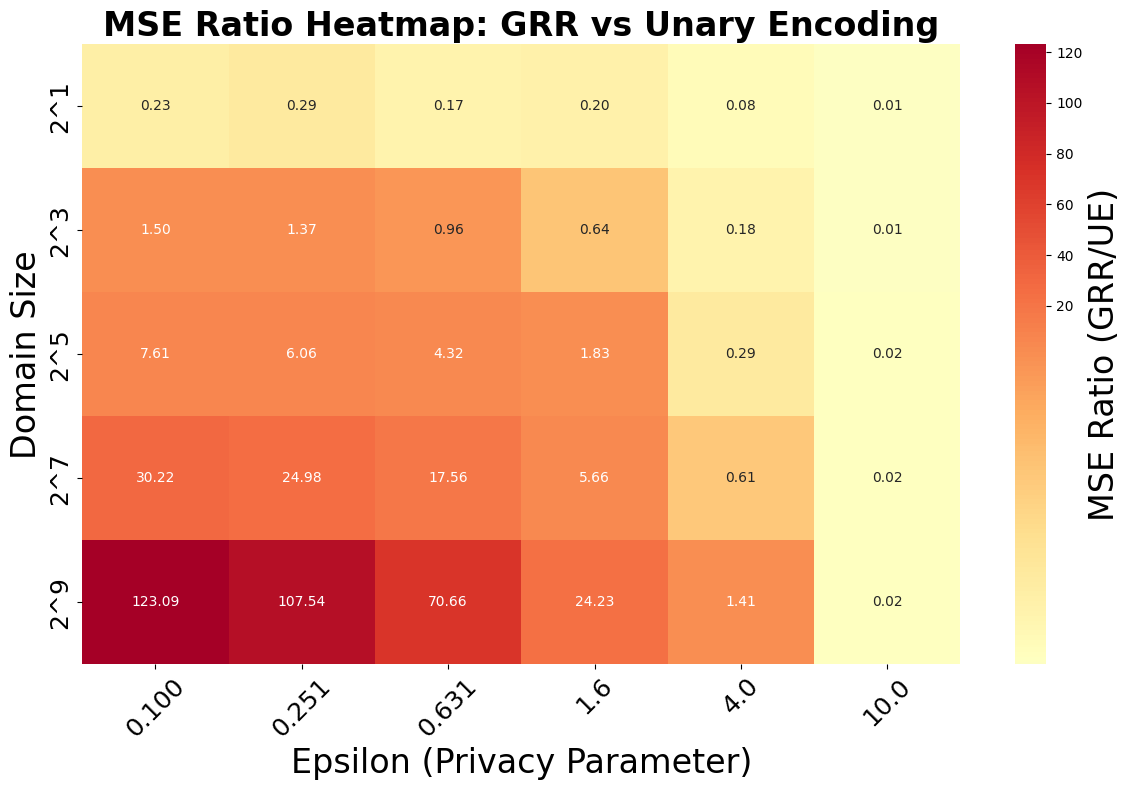

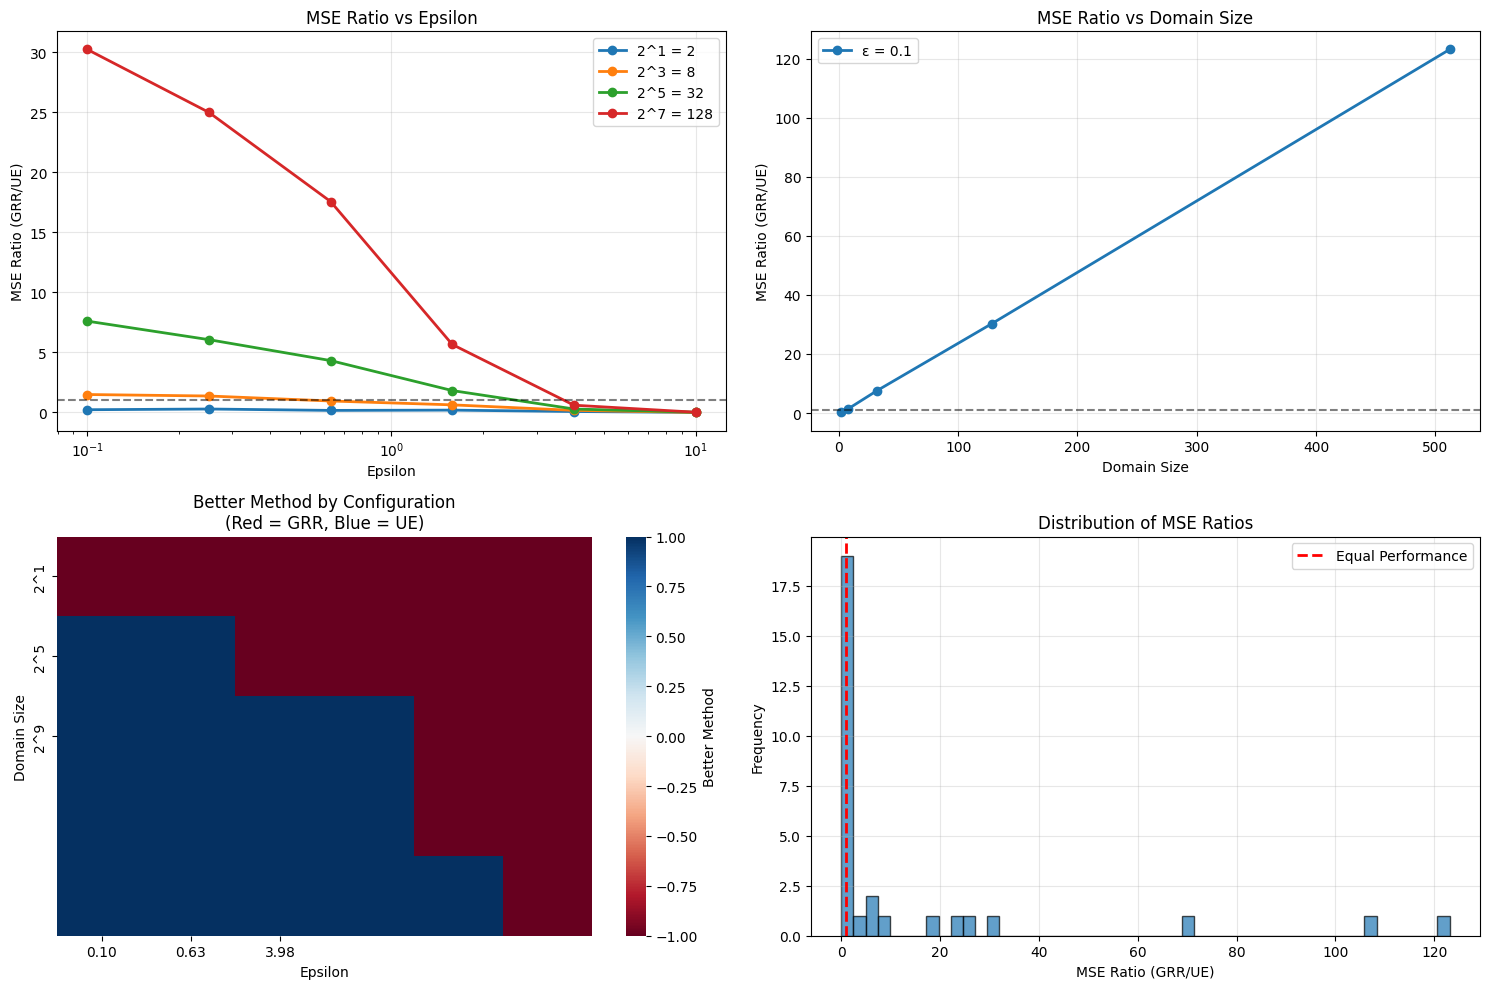


COMPREHENSIVE ANALYSIS SUMMARY
Total configurations tested: 30
Epsilon range: 0.100 to 10.0
Domain size range: 2^1 to 2^10 (2 to 512)

Overall Performance:
  GRR performs better: 15/30 (50.0%)
  UE performs better: 15/30 (50.0%)
  Equal performance: 0/30 (0.0%)

Best GRR performance (lowest ratio):
  MSE Ratio: 0.010
  Epsilon: 10.000, Domain Size: 8.0
  GRR MSE: 0.000000, UE MSE: 0.000001

Worst GRR performance (highest ratio):
  MSE Ratio: 123.087
  Epsilon: 0.100, Domain Size: 512.0
  GRR MSE: 5.012127, UE MSE: 0.040720

Performance by Privacy Level:
  High Privacy (ε ≤ 0.5): GRR better in 2/10 cases (20.0%)
  Medium Privacy (0.5 < ε ≤ 2.0): GRR better in 4/10 cases (40.0%)
  Low Privacy (ε > 2.0): GRR better in 9/10 cases (90.0%)

Performance by Domain Size:
  Small Domain (2^1 to 2^3): GRR better in 10/12 cases (83.3%)
  Medium Domain (2^4 to 2^6): GRR better in 2/6 cases (33.3%)
  Large Domain (2^7 to 2^10): GRR better in 3/12 cases (25.0%)

Analysis complete in QUICK mode!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
from tqdm import tqdm
import warnings
from multiprocessing import Pool, cpu_count
from functools import partial
import concurrent.futures
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

class GeneralizedRandomizedResponse:
    """
    Generalized Randomized Response (GRR) mechanism for differential privacy
    """
    def __init__(self, epsilon, domain_size):
        self.epsilon = epsilon
        self.domain_size = domain_size
        self.p = np.exp(epsilon) / (np.exp(epsilon) + domain_size - 1)
        self.q = 1 / (np.exp(epsilon) + domain_size - 1)

    def perturb(self, data):
        """Apply GRR perturbation to the data"""
        perturbed_data = []
        for value in data:
            if np.random.random() < self.p:
                # Keep the true value
                perturbed_data.append(value)
            else:
                # Choose a random value from domain (excluding true value)
                domain = list(range(self.domain_size))
                domain.remove(value)
                perturbed_data.append(np.random.choice(domain))
        return np.array(perturbed_data)

    def estimate_frequency(self, perturbed_data, n):
        """Estimate true frequencies from perturbed data"""
        observed_counts = Counter(perturbed_data)
        estimated_frequencies = {}

        for i in range(self.domain_size):
            observed_freq = observed_counts.get(i, 0) / n
            # Unbiased estimator for GRR
            estimated_freq = (observed_freq - self.q) / (self.p - self.q)
            estimated_frequencies[i] = max(0, estimated_freq)  # Ensure non-negative

        return estimated_frequencies

class UnaryEncoding:
    """
    Unary Encoding mechanism for differential privacy
    """
    def __init__(self, epsilon, domain_size):
        self.epsilon = epsilon
        self.domain_size = domain_size
        self.p = np.exp(epsilon / 2) / (np.exp(epsilon / 2) + 1)
        self.q = 1 / (np.exp(epsilon / 2) + 1)

    def perturb(self, data):
        """Apply Unary Encoding perturbation to the data"""
        perturbed_data = []
        for value in data:
            # Create unary encoding vector
            unary_vector = np.zeros(self.domain_size)
            unary_vector[value] = 1

            # Apply randomized response to each bit
            perturbed_vector = []
            for bit in unary_vector:
                if bit == 1:
                    perturbed_bit = 1 if np.random.random() < self.p else 0
                else:
                    perturbed_bit = 1 if np.random.random() < self.q else 0
                perturbed_vector.append(perturbed_bit)

            perturbed_data.append(perturbed_vector)

        return np.array(perturbed_data)

    def estimate_frequency(self, perturbed_data, n):
        """Estimate true frequencies from perturbed unary encoded data"""
        estimated_frequencies = {}

        for i in range(self.domain_size):
            # Sum of perturbed bits for position i
            sum_bits = np.sum(perturbed_data[:, i])
            observed_freq = sum_bits / n

            # Unbiased estimator for Unary Encoding
            estimated_freq = (observed_freq - self.q) / (self.p - self.q)
            estimated_frequencies[i] = max(0, estimated_freq)  # Ensure non-negative

        return estimated_frequencies

def generate_synthetic_data(n_samples, domain_size, distribution_type='uniform'):
    """
    Generate synthetic categorical data with different distributions

    Args:
        n_samples: Number of samples to generate
        domain_size: Number of categories
        distribution_type: 'uniform', 'skewed', or 'zipf'
    """
    if distribution_type == 'uniform':
        # Uniform distribution
        data = np.random.randint(0, domain_size, n_samples)
    elif distribution_type == 'skewed':
        # Skewed distribution (exponential decay)
        probs = np.exp(-np.arange(domain_size) * 0.5)
        probs = probs / probs.sum()
        data = np.random.choice(domain_size, n_samples, p=probs)
    elif distribution_type == 'zipf':
        # Zipf distribution (power law)
        probs = 1 / (np.arange(domain_size) + 1)
        probs = probs / probs.sum()
        data = np.random.choice(domain_size, n_samples, p=probs)
    else:
        raise ValueError("distribution_type must be 'uniform', 'skewed', or 'zipf'")

    return data

def run_single_trial(args):
    """
    Run a single trial for both GRR and UE - optimized for parallel execution
    """
    epsilon, domain_size, data, true_frequencies, trial_id = args

    # Set different random seed for each trial to avoid identical results
    np.random.seed(42 + trial_id + int(epsilon * 1000) + domain_size)

    # GRR experiment
    grr = GeneralizedRandomizedResponse(epsilon, domain_size)
    grr_perturbed = grr.perturb(data)
    grr_estimated = grr.estimate_frequency(grr_perturbed, len(data))
    grr_mse = calculate_mse(true_frequencies, grr_estimated, domain_size)

    # Unary Encoding experiment
    ue = UnaryEncoding(epsilon, domain_size)
    ue_perturbed = ue.perturb(data)
    ue_estimated = ue.estimate_frequency(ue_perturbed, len(data))
    ue_mse = calculate_mse(true_frequencies, ue_estimated, domain_size)

    return grr_mse, ue_mse

def run_configuration_batch(config_args):
    """
    Run all trials for a single configuration (epsilon, domain_size) - vectorized approach
    """
    epsilon, domain_size, n_samples, n_trials, distribution_type = config_args

    # Generate data once for this configuration
    data = generate_synthetic_data(n_samples, domain_size, distribution_type)
    true_counts = Counter(data)
    true_frequencies = {i: true_counts.get(i, 0) / n_samples for i in range(domain_size)}

    # Prepare arguments for parallel trials
    trial_args = [(epsilon, domain_size, data, true_frequencies, trial)
                  for trial in range(n_trials)]

    # Run trials in parallel
    with concurrent.futures.ThreadPoolExecutor(max_workers=min(n_trials, cpu_count())) as executor:
        results = list(executor.map(run_single_trial, trial_args))

    # Extract results
    grr_mse_trials = [r[0] for r in results]
    ue_mse_trials = [r[1] for r in results]

    # Calculate averages
    avg_grr_mse = np.mean(grr_mse_trials)
    avg_ue_mse = np.mean(ue_mse_trials)
    mse_ratio = avg_grr_mse / avg_ue_mse if avg_ue_mse > 0 else np.inf

    return {
        'epsilon': epsilon,
        'domain_size': domain_size,
        'grr_mse': avg_grr_mse,
        'ue_mse': avg_ue_mse,
        'mse_ratio': mse_ratio
    }

def calculate_mse(true_freq, estimated_freq, domain_size):
    """Calculate Mean Squared Error between true and estimated frequencies"""
    mse = 0
    for i in range(domain_size):
        true_f = true_freq.get(i, 0)
        est_f = estimated_freq.get(i, 0)
        mse += (true_f - est_f) ** 2
    return mse / domain_size

def run_comprehensive_experiment_quick():
    """
    Quick mode: Fast results with fewer parameters for rapid prototyping
    """
    # QUICK MODE parameters - minimal for fast results
    epsilon_values = np.logspace(-1, 1, 6)  # Just 6 epsilon points: 0.1, 0.25, 0.63, 1.6, 4.0, 10.0
    domain_sizes = [2**i for i in [1,  3,  5,  7,  9]]  # Just 5 domain sizes: 2, 8, 32, 128, 512
    n_samples = 5000  # Smaller sample size
    n_trials = 50  # Fewer trials
    distribution_type = 'skewed'

    print("Starting QUICK MODE experiment...")
    print(f"CPU cores available: {cpu_count()}")
    print(f"Epsilon values: {len(epsilon_values)} points: {[f'{e:.2f}' for e in epsilon_values]}")
    print(f"Domain sizes: {len(domain_sizes)} sizes: {domain_sizes}")
    print(f"Samples per experiment: {n_samples}")
    print(f"Trials per configuration: {n_trials}")
    print(f"Total configurations: {len(epsilon_values) * len(domain_sizes)}")
    print(f"Estimated time: ~30-60 seconds")

    # Prepare all configurations
    configurations = []
    for epsilon in epsilon_values:
        for domain_size in domain_sizes:
            configurations.append((epsilon, domain_size, n_samples, n_trials, distribution_type))

    print(f"Running {len(configurations)} configurations in parallel...")

    # Run all configurations in parallel
    with concurrent.futures.ProcessPoolExecutor(max_workers=min(cpu_count(), len(configurations))) as executor:
        results = list(tqdm(
            executor.map(run_configuration_batch, configurations),
            total=len(configurations),
            desc="Quick configs"
        ))

    # Convert results to DataFrame
    df = pd.DataFrame(results)

    return df, epsilon_values, domain_sizes

def run_comprehensive_experiment_fast():
    """
    Run comprehensive experiment with optimizations for speed and memory usage
    """
    # Experimental parameters - INCREASED for more RAM
    epsilon_values = np.logspace(-2, 1, 20)  # More epsilon points
    domain_sizes = [2**i for i in range(1, 11)]  # [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
    n_samples = 15000  # Increased sample size
    n_trials = 50  # Increased trials for better statistics
    distribution_type = 'skewed'

    print("Starting FAST comprehensive experiment with MORE RAM...")
    print(f"CPU cores available: {cpu_count()}")
    print(f"Epsilon values: {len(epsilon_values)} points")
    print(f"Domain sizes: {domain_sizes}")
    print(f"Samples per experiment: {n_samples}")
    print(f"Trials per configuration: {n_trials}")
    print(f"Total configurations: {len(epsilon_values) * len(domain_sizes)}")
    print(f"Total experiments: {len(epsilon_values) * len(domain_sizes) * n_trials * 2}")

    # Prepare all configurations
    configurations = []
    for epsilon in epsilon_values:
        for domain_size in domain_sizes:
            configurations.append((epsilon, domain_size, n_samples, n_trials, distribution_type))

    print(f"Running {len(configurations)} configurations in parallel...")

    # Run all configurations in parallel using all available CPU cores
    with concurrent.futures.ProcessPoolExecutor(max_workers=cpu_count()) as executor:
        results = list(tqdm(
            executor.map(run_configuration_batch, configurations),
            total=len(configurations),
            desc="Configurations"
        ))

    # Convert results to DataFrame
    df = pd.DataFrame(results)

    return df, epsilon_values, domain_sizes

def run_comprehensive_experiment():
    """
    Original experiment - standard mode
    """
    # Standard parameters
    epsilon_values = np.logspace(-2, 1, 15)  # From 0.01 to 10
    domain_sizes = [2**i for i in range(1, 11)]  # [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
    n_samples = 10000
    n_trials = 20
    distribution_type = 'skewed'

    print("Starting standard experiment...")
    print(f"Epsilon values: {len(epsilon_values)} points from {epsilon_values[0]:.3f} to {epsilon_values[-1]:.1f}")
    print(f"Domain sizes: {domain_sizes}")
    print(f"Samples per experiment: {n_samples}")
    print(f"Trials per configuration: {n_trials}")
    print(f"Distribution type: {distribution_type}")
    print(f"Total experiments: {len(epsilon_values) * len(domain_sizes) * n_trials * 2}")

    # Initialize results storage
    results = {
        'epsilon': [],
        'domain_size': [],
        'grr_mse': [],
        'ue_mse': [],
        'mse_ratio': []
    }

    # Progress bar
    total_configs = len(epsilon_values) * len(domain_sizes)
    pbar = tqdm(total=total_configs, desc="Configurations")

    for epsilon in epsilon_values:
        for domain_size in domain_sizes:
            grr_mse_trials = []
            ue_mse_trials = []

            # Generate synthetic data for this configuration
            data = generate_synthetic_data(n_samples, domain_size, distribution_type)

            # Calculate true frequencies
            true_counts = Counter(data)
            true_frequencies = {i: true_counts.get(i, 0) / n_samples for i in range(domain_size)}

            # Run trials
            for trial in range(n_trials):
                # GRR experiment
                grr = GeneralizedRandomizedResponse(epsilon, domain_size)
                grr_perturbed = grr.perturb(data)
                grr_estimated = grr.estimate_frequency(grr_perturbed, n_samples)
                grr_mse = calculate_mse(true_frequencies, grr_estimated, domain_size)
                grr_mse_trials.append(grr_mse)

                # Unary Encoding experiment
                ue = UnaryEncoding(epsilon, domain_size)
                ue_perturbed = ue.perturb(data)
                ue_estimated = ue.estimate_frequency(ue_perturbed, n_samples)
                ue_mse = calculate_mse(true_frequencies, ue_estimated, domain_size)
                ue_mse_trials.append(ue_mse)

            # Store average results
            avg_grr_mse = np.mean(grr_mse_trials)
            avg_ue_mse = np.mean(ue_mse_trials)
            mse_ratio = avg_grr_mse / avg_ue_mse if avg_ue_mse > 0 else np.inf

            results['epsilon'].append(epsilon)
            results['domain_size'].append(domain_size)
            results['grr_mse'].append(avg_grr_mse)
            results['ue_mse'].append(avg_ue_mse)
            results['mse_ratio'].append(mse_ratio)

            pbar.update(1)

    pbar.close()

    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(results)

    return df, epsilon_values, domain_sizes

def create_heatmap_visualizations(df, epsilon_values, domain_sizes):
    """
    Create MSE ratio heatmap and save as high-quality PNG
    """
    # Create pivot table for heatmap
    pivot_ratio = df.pivot(index='domain_size', columns='epsilon', values='mse_ratio')

    # Create figure with single heatmap
    plt.figure(figsize=(12, 8))

    # Create custom colormap centered at 1
    from matplotlib.colors import TwoSlopeNorm
    vmin, vmax = pivot_ratio.min().min(), pivot_ratio.max().max()
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

    ax = sns.heatmap(pivot_ratio,
                    annot=True,
                    fmt='.2f',
                    cmap='RdYlBu_r',
                    center=1,
                    norm=norm,
                    cbar_kws={'label': 'MSE Ratio (GRR/UE)'})
    colorbar = ax.collections[0].colorbar
    colorbar.ax.set_ylabel('MSE Ratio (GRR/UE)', fontsize=24)

    plt.title('MSE Ratio Heatmap: GRR vs Unary Encoding',
              fontsize=24, fontweight='bold')
    plt.xlabel('Epsilon (Privacy Parameter)', fontsize=24)
    plt.ylabel('Domain Size', fontsize=24)

    # Format x-axis labels
    x_labels = [f'{eps:.3f}' if eps < 1 else f'{eps:.1f}' for eps in epsilon_values]
    plt.gca().set_xticklabels(x_labels, rotation=45, fontsize=18, fontname='Courier New')


    # Format y-axis labels to show powers of 2
    y_labels = [f'2^{int(np.log2(d))}' for d in domain_sizes]
    plt.gca().set_yticklabels(y_labels, fontsize=18, fontname='Courier New')

    plt.tight_layout()

    # Save as high-quality PNG
    plt.savefig('mse_ratio_heatmap.png', dpi=600, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print("Heatmap saved as 'mse_ratio_heatmap.png' at 600 DPI")

    plt.show()

    # Create additional analysis plots (optional - can be commented out)
    fig2, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: MSE ratio vs epsilon for different domain sizes
    for domain_power in [1, 3, 5, 7, 10]:  # 2^1, 2^3, 2^5, 2^7, 2^10
        domain_size = 2**domain_power
        if domain_size in domain_sizes:
            subset = df[df['domain_size'] == domain_size]
            axes[0, 0].semilogx(subset['epsilon'], subset['mse_ratio'],
                               'o-', label=f'2^{domain_power} = {domain_size}', linewidth=2)

    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_xlabel('Epsilon')
    axes[0, 0].set_ylabel('MSE Ratio (GRR/UE)')
    axes[0, 0].set_title('MSE Ratio vs Epsilon')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: MSE ratio vs domain size for different epsilons
    for epsilon in [0.1, 0.5, 1.0, 5.0]:
        subset = df[np.isclose(df['epsilon'], epsilon, rtol=0.1)]
        if len(subset) > 0:
            axes[0, 1].plot(subset['domain_size'], subset['mse_ratio'],
                           'o-', label=f'ε = {epsilon}', linewidth=2)

    axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('Domain Size')
    axes[0, 1].set_ylabel('MSE Ratio (GRR/UE)')
    axes[0, 1].set_title('MSE Ratio vs Domain Size')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Regions where each method is better
    better_grr = (pivot_ratio < 1).astype(int)
    better_ue = (pivot_ratio > 1).astype(int)

    # Create a combined plot showing regions
    combined = better_ue - better_grr  # +1 where UE is better, -1 where GRR is better

    sns.heatmap(combined,
                cmap='RdBu',
                center=0,
                ax=axes[1, 0],
                cbar_kws={'label': 'Better Method'},
                xticklabels=[f'{eps:.2f}' for eps in epsilon_values[::2]],
                yticklabels=[f'2^{int(np.log2(d))}' for d in domain_sizes[::2]])
    axes[1, 0].set_title('Better Method by Configuration\n(Red = GRR, Blue = UE)')
    axes[1, 0].set_xlabel('Epsilon')
    axes[1, 0].set_ylabel('Domain Size')

    # Plot 4: Distribution of MSE ratios
    axes[1, 1].hist(df['mse_ratio'], bins=50, alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Equal Performance')
    axes[1, 1].set_xlabel('MSE Ratio (GRR/UE)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of MSE Ratios')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_analysis_summary(df, epsilon_values, domain_sizes):
    """
    Print detailed analysis summary
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE ANALYSIS SUMMARY")
    print("="*80)

    # Overall statistics
    print(f"Total configurations tested: {len(df)}")
    print(f"Epsilon range: {epsilon_values[0]:.3f} to {epsilon_values[-1]:.1f}")
    print(f"Domain size range: 2^1 to 2^10 ({min(domain_sizes)} to {max(domain_sizes)})")

    # Performance comparison
    grr_better = (df['mse_ratio'] < 1).sum()
    ue_better = (df['mse_ratio'] > 1).sum()
    equal = (df['mse_ratio'] == 1).sum()

    print(f"\nOverall Performance:")
    print(f"  GRR performs better: {grr_better}/{len(df)} ({grr_better/len(df)*100:.1f}%)")
    print(f"  UE performs better: {ue_better}/{len(df)} ({ue_better/len(df)*100:.1f}%)")
    print(f"  Equal performance: {equal}/{len(df)} ({equal/len(df)*100:.1f}%)")

    # Best and worst ratios
    best_grr = df.loc[df['mse_ratio'].idxmin()]
    worst_grr = df.loc[df['mse_ratio'].idxmax()]

    print(f"\nBest GRR performance (lowest ratio):")
    print(f"  MSE Ratio: {best_grr['mse_ratio']:.3f}")
    print(f"  Epsilon: {best_grr['epsilon']:.3f}, Domain Size: {best_grr['domain_size']}")
    print(f"  GRR MSE: {best_grr['grr_mse']:.6f}, UE MSE: {best_grr['ue_mse']:.6f}")

    print(f"\nWorst GRR performance (highest ratio):")
    print(f"  MSE Ratio: {worst_grr['mse_ratio']:.3f}")
    print(f"  Epsilon: {worst_grr['epsilon']:.3f}, Domain Size: {worst_grr['domain_size']}")
    print(f"  GRR MSE: {worst_grr['grr_mse']:.6f}, UE MSE: {worst_grr['ue_mse']:.6f}")

    # Analysis by epsilon ranges
    print(f"\nPerformance by Privacy Level:")

    high_privacy = df[df['epsilon'] <= 0.5]
    medium_privacy = df[(df['epsilon'] > 0.5) & (df['epsilon'] <= 2.0)]
    low_privacy = df[df['epsilon'] > 2.0]

    for name, subset in [("High Privacy (ε ≤ 0.5)", high_privacy),
                        ("Medium Privacy (0.5 < ε ≤ 2.0)", medium_privacy),
                        ("Low Privacy (ε > 2.0)", low_privacy)]:
        if len(subset) > 0:
            grr_wins = (subset['mse_ratio'] < 1).sum()
            print(f"  {name}: GRR better in {grr_wins}/{len(subset)} cases ({grr_wins/len(subset)*100:.1f}%)")

    # Analysis by domain size ranges
    print(f"\nPerformance by Domain Size:")

    small_domain = df[df['domain_size'] <= 8]  # 2^1 to 2^3
    medium_domain = df[(df['domain_size'] > 8) & (df['domain_size'] <= 64)]  # 2^4 to 2^6
    large_domain = df[df['domain_size'] > 64]  # 2^7 to 2^10

    for name, subset in [("Small Domain (2^1 to 2^3)", small_domain),
                        ("Medium Domain (2^4 to 2^6)", medium_domain),
                        ("Large Domain (2^7 to 2^10)", large_domain)]:
        if len(subset) > 0:
            grr_wins = (subset['mse_ratio'] < 1).sum()
            print(f"  {name}: GRR better in {grr_wins}/{len(subset)} cases ({grr_wins/len(subset)*100:.1f}%)")

# Run the complete analysis
if __name__ == "__main__":
    print("Starting comprehensive GRR vs UE analysis...")

    # Choose execution mode
    MODE = input("What mode do you want? Options: QUICK, FAST, STANDARD ")  # Options: "QUICK", "FAST", "STANDARD"

    if MODE == "QUICK":
        print("Using QUICK MODE for rapid prototyping...")
        df, epsilon_values, domain_sizes = run_comprehensive_experiment_quick()
    elif MODE == "FAST":
        print("Using FAST MODE with parallel processing...")
        df, epsilon_values, domain_sizes = run_comprehensive_experiment_fast()
    else:  # STANDARD
        print("Using STANDARD mode...")
        df, epsilon_values, domain_sizes = run_comprehensive_experiment()

    # Create visualizations
    print("\nCreating visualizations...")
    create_heatmap_visualizations(df, epsilon_values, domain_sizes)

    # Print analysis
    print_analysis_summary(df, epsilon_values, domain_sizes)

    print(f"\nAnalysis complete in {MODE} mode!")